In [1]:
import pandas as pd
import matplotlib
import ast
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
# colors_main = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

In [2]:
#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [3]:
full = pd.read_csv('./preprocessed_final.csv')

In [4]:
full.info()

<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   customer_id         306534 non-null  str    
 1   event               306534 non-null  str    
 2   time                306534 non-null  int64  
 3   amount              138953 non-null  float64
 4   actual_reward       33579 non-null   float64
 5   offer_id            167581 non-null  str    
 6   day                 306534 non-null  int64  
 7   reward              167581 non-null  float64
 8   difficulty          167581 non-null  float64
 9   duration            167581 non-null  float64
 10  offer_type          167581 non-null  str    
 11  ch_web              167581 non-null  float64
 12  ch_email            167581 non-null  float64
 13  ch_mobile           167581 non-null  float64
 14  ch_social           167581 non-null  float64
 15  channel_count       167581 non-null  float64


In [5]:
full.dtypes

customer_id               str
event                     str
time                    int64
amount                float64
actual_reward         float64
offer_id                  str
day                     int64
reward                float64
difficulty            float64
duration              float64
offer_type                str
ch_web                float64
ch_email              float64
ch_mobile             float64
ch_social             float64
channel_count         float64
reward_ratio          float64
offer_strength        float64
gender                    str
age                   float64
became_member_on          str
income                float64
is_profile_missing      int64
age_group                 str
age_gender                str
income_group              str
dtype: object

In [6]:
# 날짜 변환 (혹시 안 했으면)
full['became_member_on'] = pd.to_datetime(full['became_member_on'], errors='coerce')

# 가입 연도
full['join_year'] = full['became_member_on'].dt.year

# 가입 월 (숫자)
full['join_month'] = full['became_member_on'].dt.month

# cohort
full['join_cohort'] = full['became_member_on'].dt.to_period('M')

In [7]:
print("[ 가입 연도 분포 ]")
display(full['join_year'].value_counts().sort_index())

print("[ 가입 월 분포 ]")
display(full['join_month'].value_counts().sort_index())

print("[ Cohort 분포 ]")
display(full['join_cohort'].value_counts().sort_index())

[ 가입 연도 분포 ]


join_year
2013      6344
2014     15207
2015     38492
2016     72780
2017    113564
2018     60147
Name: count, dtype: int64

[ 가입 월 분포 ]


join_month
1     28161
2     21715
3     23366
4     23241
5     22953
6     22628
7     23984
8     29559
9     27622
10    28558
11    26386
12    28361
Name: count, dtype: int64

[ Cohort 분포 ]


join_cohort
2013-07     119
2013-08    1467
2013-09    1249
2013-10    1264
2013-11    1024
           ... 
2018-03    8505
2018-04    8176
2018-05    8370
2018-06    7831
2018-07    7085
Freq: M, Name: count, Length: 61, dtype: int64

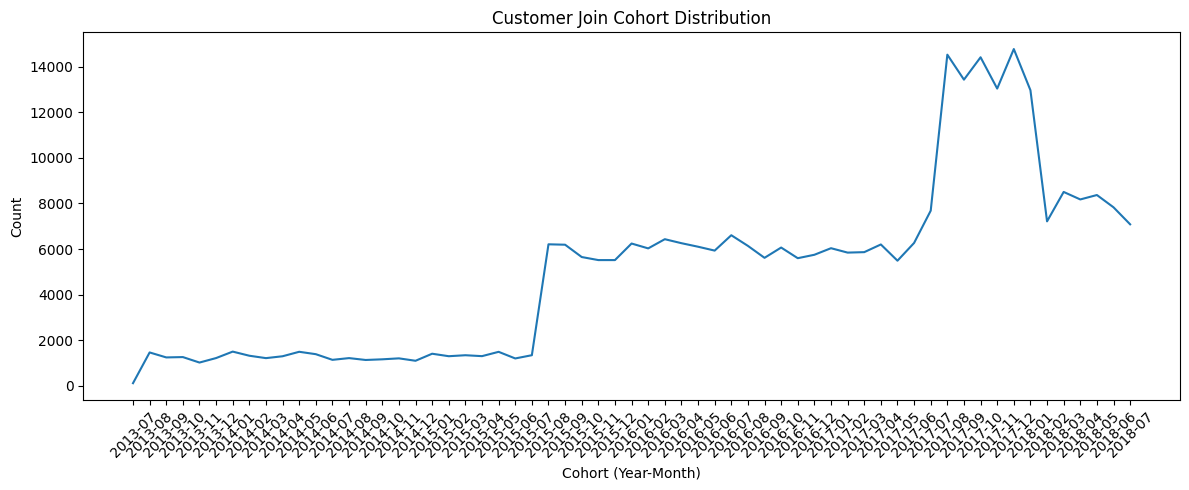

In [8]:
cohort_counts = full['join_cohort'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(cohort_counts.index.astype(str), cohort_counts.values)

plt.xticks(rotation=45)
plt.title('Customer Join Cohort Distribution')
plt.xlabel('Cohort (Year-Month)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

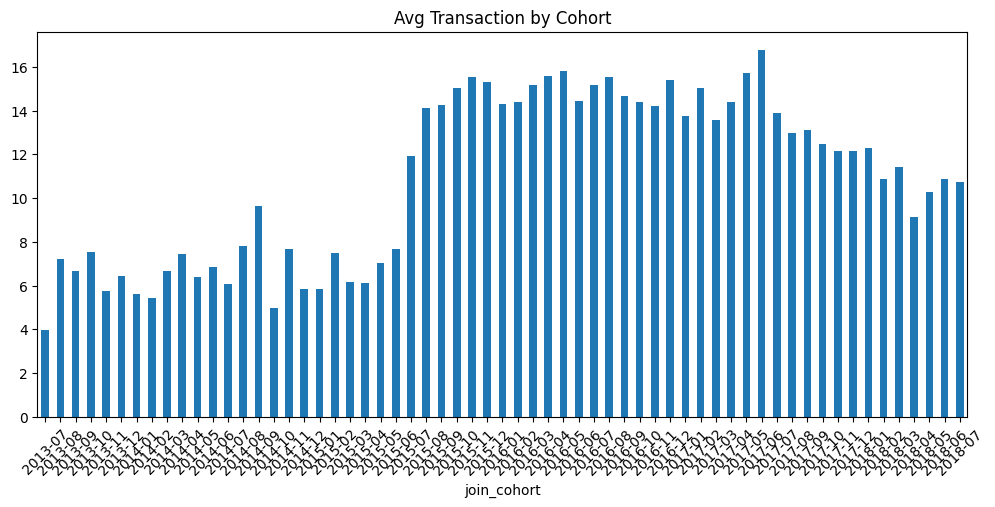

In [9]:
tx = full[full['event'] == 'transaction'].copy()

cohort_avg = (
    tx.groupby('join_cohort')['amount']
    .mean()
)

cohort_avg.plot(kind='bar', figsize=(12,5), title='Avg Transaction by Cohort')
plt.xticks(rotation=45)
plt.show()

In [10]:
full['offer_type'].value_counts() # bogo = buy one get one

offer_type
bogo             71617
discount         69898
informational    26066
Name: count, dtype: int64

In [11]:
print("=" * 50)
print("[ 기본 정보 ]")
print("=" * 50)
print(f"전체 행 수  : {len(full):,}")
print(f"고유 고객 수 : {full['customer_id'].nunique():,}")
print(f"컬럼 수     : {full.shape[1]}")

[ 기본 정보 ]
전체 행 수  : 306,534
고유 고객 수 : 17,000
컬럼 수     : 29


In [12]:
#-----------------------
# 이벤트 분포
#-----------------------

event = full['event'].value_counts()
for name, count in event.items():
    pct = count / len(full) * 100
    print(f"{name:<25} {count:>7,}건  ({pct:.1f}%)")

transaction               138,953건  (45.3%)
offer received             76,277건  (24.9%)
offer viewed               57,725건  (18.8%)
offer completed            33,579건  (11.0%)


In [13]:
# ----------------------
# 퍼널 수치
#-----------------------

n_received = full[full['event'] == 'offer received']['customer_id'].nunique()
n_viewed = full[full['event'] == 'offer viewed']['customer_id'].nunique()
n_completed = full[full['event'] == 'offer completed']['customer_id'].nunique()
n_transaction = full[full['event'] == 'transaction']['customer_id'].nunique()

print(f"오퍼 수신 고객 : {n_received:,}명")
print(f"오퍼 조회 고객 : {n_viewed:,}명 (수신 대비 {n_viewed / n_received * 100:.1f}%)")
print(f"오퍼 완료 고객 : {n_completed:,}명 (조회 대비 {n_completed / n_viewed * 100:.1f}%)")
print(f"트랜잭션 고객 : {n_transaction:,}명")

오퍼 수신 고객 : 16,994명
오퍼 조회 고객 : 16,834명 (수신 대비 99.1%)
오퍼 완료 고객 : 12,774명 (조회 대비 75.9%)
트랜잭션 고객 : 16,578명


In [14]:
# 오퍼 유형별 분포
print("=" * 50)
print("[ 오퍼 유형별 분포 ]")
print("=" * 50)
offer_ev = full[full['event'] != 'transaction'].groupby(['offer_type', 'event']).size().unstack(fill_value=0)
print(offer_ev)

[ 오퍼 유형별 분포 ]
event          offer completed  offer received  offer viewed
offer_type                                                  
bogo                     15669           30499         25449
discount                 17910           30543         21445
informational                0           15235         10831


In [15]:
# 오퍼 유형별 완료율
for oftype in ['bogo', 'discount']:
    df_o = full[full['offer_type'] == oftype]
    r = df_o[df_o['event'] == 'offer received']['customer_id'].nunique()
    c = df_o[df_o['event'] == 'offer completed']['customer_id'].nunique()
    print(f"  {oftype:<12} 수신 {r:,}명  완료 {c:,}명  완료율 {c/r*100:.1f}%")


  bogo         수신 14,992명  완료 9,263명  완료율 61.8%
  discount     수신 14,945명  완료 10,289명  완료율 68.8%


In [16]:
# 고객 단위별 집계(중복 제거)
customer = full[['customer_id','gender','age','age_group','age_gender','income','income_group']].drop_duplicates('customer_id')

print(f"총 고객 수: {len(customer):,}명")

총 고객 수: 17,000명


In [17]:
print(" [성별]")
for v, c in customer['gender'].value_counts(dropna=False).items():
    print(f"  {v:<10} {c:,}명  ({c/len(customer)*100:.1f}%)")


 [성별]
  M          8,484명  (49.9%)
  F          6,129명  (36.1%)
  Unknown    2,175명  (12.8%)
  O          212명  (1.2%)


In [18]:
gender_df = (
    customer['gender']
    .value_counts(dropna=False)
    .rename_axis('gender')
    .reset_index(name='count')
)

# 비율 추가
gender_df['ratio'] = gender_df['count'] / len(customer) * 100
gender_df

,gender,count,ratio
0,M,8484,49.905882
1,F,6129,36.052941
2,Unknown,2175,12.794118
3,O,212,1.247059


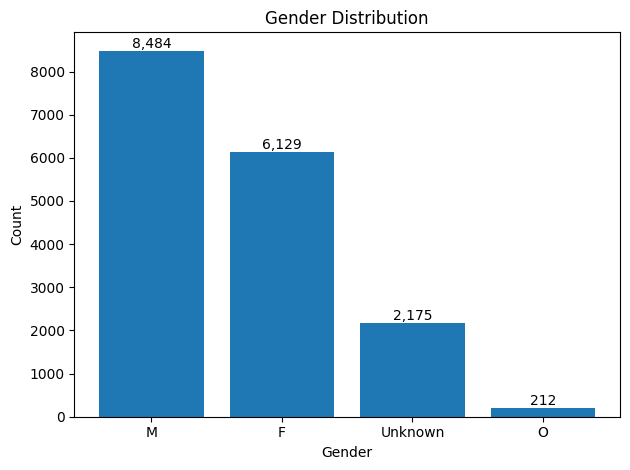

In [19]:
plt.figure()
plt.bar(gender_df['gender'], gender_df['count'])

# 값 표시
for i, v in enumerate(gender_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [20]:
print("[ 연령대 ]")
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상', '누락']
for v in age_order:
    c = (customer['age_group'] == v).sum()
    print(f"    {v:<8} {c:>5,}명  ({c/len(customer)*100:.1f}%)")

[ 연령대 ]
    20대 미만     205명  (1.2%)
    20대      1,369명  (8.1%)
    30대      1,526명  (9.0%)
    40대      2,309명  (13.6%)
    50대      3,541명  (20.8%)
    60대 이상   5,875명  (34.6%)
    누락       2,175명  (12.8%)


In [21]:
age_df = (
    customer['age_group']
    .value_counts(dropna=False)
    .rename_axis('age_group')
    .reset_index(name='count')
)
# 순서 지정 
age_df['age_group'] = pd.Categorical(age_df['age_group'], categories=age_order, ordered=True)

# 정렬
age_df = age_df.sort_values('age_group')

# 비율 추가
age_df['ratio'] = age_df['count'] / len(customer) * 100

age_df

,age_group,count,ratio
6,20대 미만,205,1.205882
5,20대,1369,8.052941
4,30대,1526,8.976471
2,40대,2309,13.582353
1,50대,3541,20.829412
0,60대 이상,5875,34.558824
3,누락,2175,12.794118


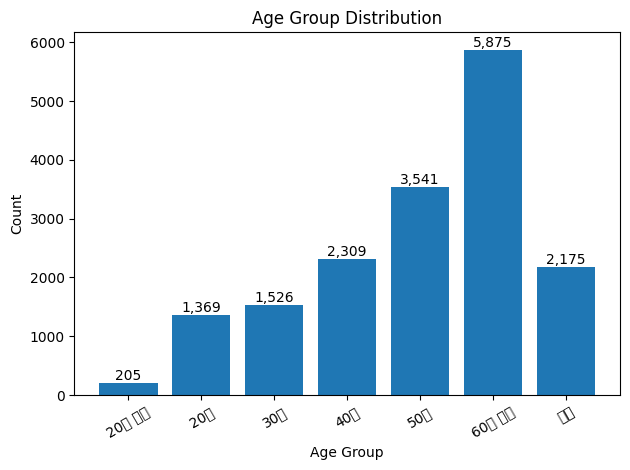

In [22]:
plt.figure()
plt.bar(age_df['age_group'], age_df['count'])

# 값 표시
for i, v in enumerate(age_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
print(f"\n  나이 기술통계 (누락 제외):")
age_valid = customer[customer['age_group'] != '누락']['age']
print(f"    평균 {age_valid.mean():.1f}세 / 중앙값 {age_valid.median():.0f}세 / 최소 {age_valid.min():.0f}세 / 최대 {age_valid.max():.0f}세")


  나이 기술통계 (누락 제외):
    평균 54.4세 / 중앙값 55세 / 최소 18세 / 최대 101세


In [24]:
print(" [ 소득 구간 ]")
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
for v in inc_order:
    c = (customer['income_group'] == v).sum()
    print(f"    {v:<10} {c:>5,}명  ({c/len(customer)*100:.1f}%)")

 [ 소득 구간 ]
    누락         2,175명  (12.8%)
    5만 미만      3,781명  (22.2%)
    5-7.5만     6,446명  (37.9%)
    7.5-10만    3,505명  (20.6%)
    10만 이상     1,093명  (6.4%)


In [25]:
age_gender_order = ['미기입', 'Others']

age_bins = ['20세 미만', '20대', '30대', '40대', '50대', '60대', '60+']
genders = ['남성', '여성']

for g in genders:
    for a in age_bins:
        age_gender_order.append(f"{a} {g}")

In [26]:
# 고객 단위 집계 (full['age_gender'] 쓰면 이벤트 row 가중됨)
result = customer['age_gender'].value_counts().reindex(age_gender_order, fill_value=0)
print("[ 연령 × 성별 구간 ]")
for v, c in result.items():
    print(f"    {v:<15} {c:>5,}명  ({c/len(customer)*100:.1f}%)")

[ 연령 × 성별 구간 ]
    미기입             2,175명  (12.8%)
    Others            212명  (1.2%)
    20세 미만 남성         160명  (0.9%)
    20대 남성            960명  (5.6%)
    30대 남성          1,008명  (5.9%)
    40대 남성          1,434명  (8.4%)
    50대 남성          1,925명  (11.3%)
    60대 남성          1,602명  (9.4%)
    60+ 남성          1,395명  (8.2%)
    20세 미만 여성          45명  (0.3%)
    20대 여성            393명  (2.3%)
    30대 여성            495명  (2.9%)
    40대 여성            835명  (4.9%)
    50대 여성          1,560명  (9.2%)
    60대 여성          1,350명  (7.9%)
    60+ 여성          1,451명  (8.5%)


In [27]:
# 고객 단위 집계 (이벤트 row 가중 방지)
df_age_gender = (
    customer['age_gender']
    .value_counts()
    .reindex(age_gender_order, fill_value=0)
    .to_frame(name='count')
)
df_age_gender['ratio(%)'] = (df_age_gender['count'] / len(customer) * 100).round(1)
display(df_age_gender)

,count,ratio(%)
age_gender,,
미기입,2175,12.8
Others,212,1.2
20세 미만 남성,160,0.9
20대 남성,960,5.6
30대 남성,1008,5.9
40대 남성,1434,8.4
50대 남성,1925,11.3
60대 남성,1602,9.4
60+ 남성,1395,8.2


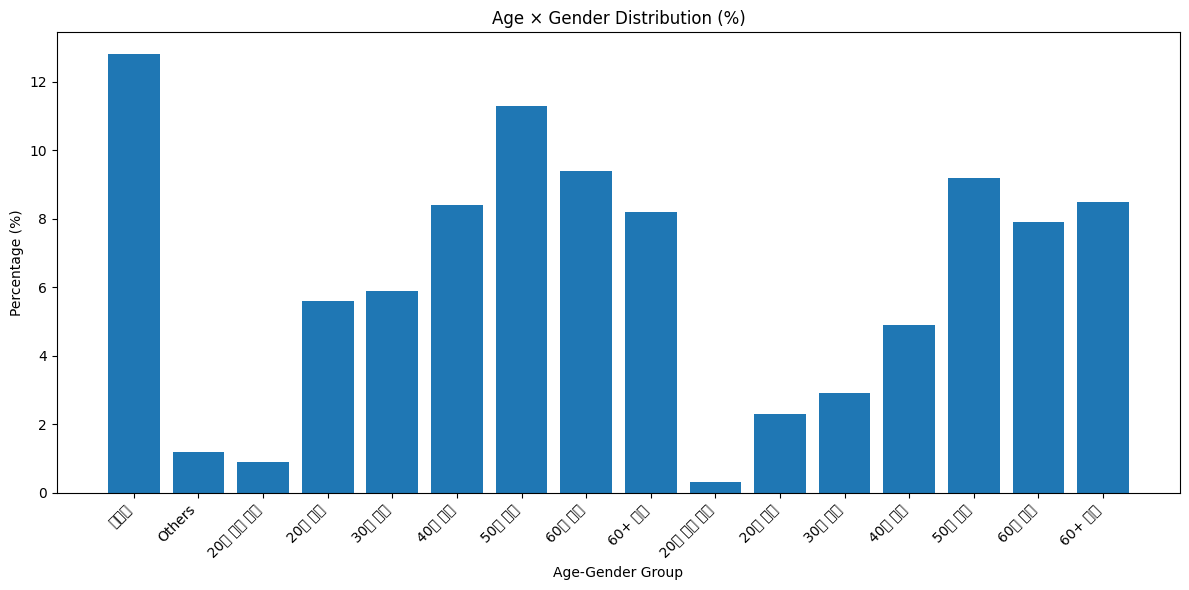

In [28]:
plt.figure(figsize=(12,6))

plt.bar(df_age_gender.index, df_age_gender['ratio(%)'])

plt.xticks(rotation=45, ha='right')
plt.title('Age × Gender Distribution (%)')
plt.xlabel('Age-Gender Group')
plt.ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

In [29]:
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']

# count 계산 (순서 유지)
inc_df = pd.DataFrame({
    'income_group': inc_order,
    'count': [(customer['income_group'] == v).sum() for v in inc_order]
})

# 비율 추가
inc_df['ratio'] = inc_df['count'] / len(customer) * 100

inc_df

,income_group,count,ratio
0,누락,2175,12.794118
1,5만 미만,3781,22.241176
2,5-7.5만,6446,37.917647
3,7.5-10만,3505,20.617647
4,10만 이상,1093,6.429412


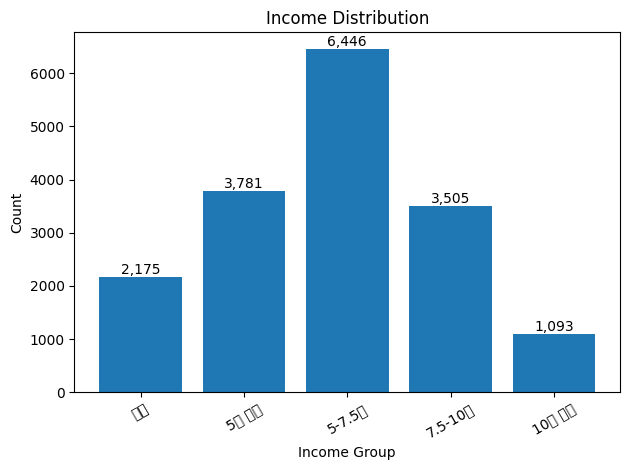

In [30]:
plt.figure()
plt.bar(inc_df['income_group'], inc_df['count'])

# 값 표시
for i, v in enumerate(inc_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Income Distribution')
plt.xlabel('Income Group')
plt.ylabel('Count')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [31]:
print(f"누락 제외:")
inc_valid = customer[customer['income_group'] != '누락']['income']
print(f" 평균 ${inc_valid.mean():,.0f} , 중앙값 ${inc_valid.median():,.0f} , 최소 ${inc_valid.min():,.0f} , 최대 ${inc_valid.max():,.0f}")

누락 제외:
 평균 $65,405 , 중앙값 $64,000 , 최소 $30,000 , 최대 $120,000


In [32]:
#거래 금액 분포 
print( "=" * 50)
print("[ 거래 금액 분포 ]")
print("=" * 50)
tx = full[full['event'] == 'transaction']['amount']
print(f"  거래 건수  : {len(tx):,}건")
print(f"  평균       : ${tx.mean():.2f}")
print(f"  중앙값     : ${tx.median():.2f}")
print(f"  최솟값     : ${tx.min():.2f}")
print(f"  최댓값     : ${tx.max():.2f}")
print(f"  표준편차   : ${tx.std():.2f}")
print(f"  이상값(>200달러) : {(tx > 200).sum():,}건  ({(tx>200).mean()*100:.2f}%)")

# 고객별 총 거래금액
cust_tx = full[full['event'] == 'transaction'].groupby('customer_id')['amount'].sum()
print(f"\n  고객별 총 거래금액:")
print(f"    평균   : ${cust_tx.mean():.2f}")
print(f"    중앙값 : ${cust_tx.median():.2f}")
print(f"    최댓값 : ${cust_tx.max():.2f}")

[ 거래 금액 분포 ]
  거래 건수  : 138,953건
  평균       : $12.78
  중앙값     : $8.89
  최솟값     : $0.05
  최댓값     : $1062.28
  표준편차   : $30.25
  이상값(>200달러) : 371건  (0.27%)

  고객별 총 거래금액:
    평균   : $107.10
    중앙값 : $72.41
    최댓값 : $1608.69


In [33]:
#채널별 오퍼 수 
print("\n" + "=" * 55)
print("[채널별 오퍼 발송 현황 ]")
print("=" * 55)
offer_log = full[full['event'] == 'offer received']
for ch in ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']:
    cnt = offer_log[ch].sum()
    pct = cnt / len(offer_log) * 100
    print(f"  {ch:<12} {int(cnt):>7,}건  ({pct:.1f}%)")

print(f"\n  채널 수별 오퍼:")
for n, c in offer_log['channel_count'].value_counts().sort_index().items():
    print(f"    {int(n)}개 채널  {c:>7,}건  ({c/len(offer_log)*100:.1f}%)")



[채널별 오퍼 발송 현황 ]
  ch_web        61,001건  (80.0%)
  ch_email      76,277건  (100.0%)
  ch_mobile     68,609건  (89.9%)
  ch_social     45,683건  (59.9%)

  채널 수별 오퍼:
    2개 채널    7,668건  (10.1%)
    3개 채널   38,202건  (50.1%)
    4개 채널   30,407건  (39.9%)


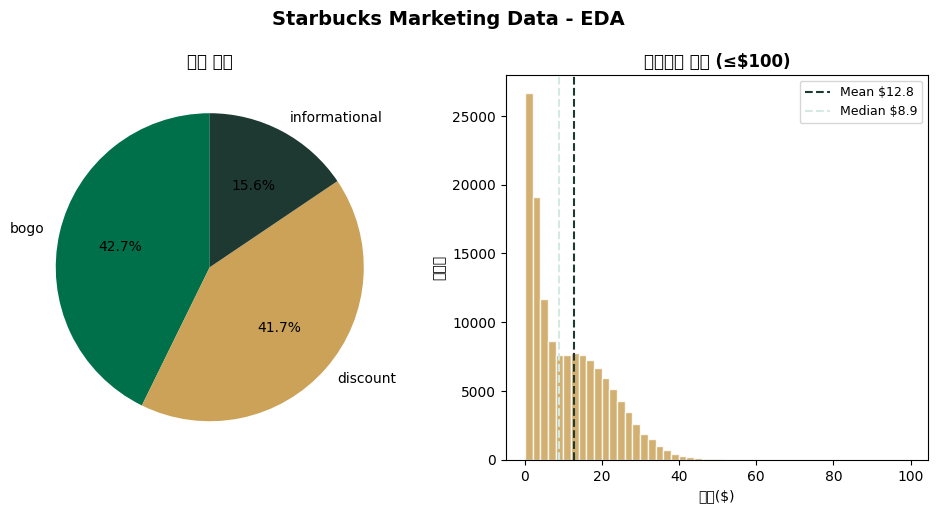

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Starbucks Marketing Data - EDA', fontsize=14, fontweight='bold', y=1.01)

# 차트 1: 오퍼 유형별
ax1 = axes[0]
ot = full[full['event'] != 'transaction']['offer_type'].value_counts()
ax1.pie(ot.values, labels=ot.index, autopct='%1.1f%%',
        colors=['#00704A', '#CBA258', '#1E3932'], startangle=90)
ax1.set_title('오퍼 유형', fontweight='bold')

# 차트 2: 거래금액 분포 (이상값 제외)
ax2 = axes[1]
tx_plot = tx[tx <= 100]
ax2.hist(tx_plot, bins=50, color='#CBA258', alpha=0.85, edgecolor='white')
ax2.axvline(tx.mean(),   color='#1E3932', linestyle='--', linewidth=1.5, label=f'Mean ${tx.mean():.1f}')
ax2.axvline(tx.median(), color='#D4E9E2', linestyle='--', linewidth=1.5, label=f'Median ${tx.median():.1f}')
ax2.set_title('거래금액 분포 (≤$100)', fontweight='bold')
ax2.set_xlabel('금액($)')
ax2.set_ylabel('카운트')
ax2.legend(fontsize=9)

In [35]:
# full DataFrame (추가 칼럼 포함) 저장
full.to_csv('./final_eda.csv', index=False)
print(f"저장 완료: final_eda.csv")
print(f"  행 수: {len(full):,}")
print(f"  칼럼 수: {full.shape[1]}")
print(f"  칼럼 목록: {list(full.columns)}")


저장 완료: final_eda.csv
  행 수: 306,534
  칼럼 수: 29
  칼럼 목록: ['customer_id', 'event', 'time', 'amount', 'actual_reward', 'offer_id', 'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength', 'gender', 'age', 'became_member_on', 'income', 'is_profile_missing', 'age_group', 'age_gender', 'income_group', 'join_year', 'join_month', 'join_cohort']
